Bits TX: [0 0 1 1 1 1 0 0 0 0]
Bits RX: [0 0 1 1 1 1 0 0 0 0]
Erros: 0
BER: 0.0


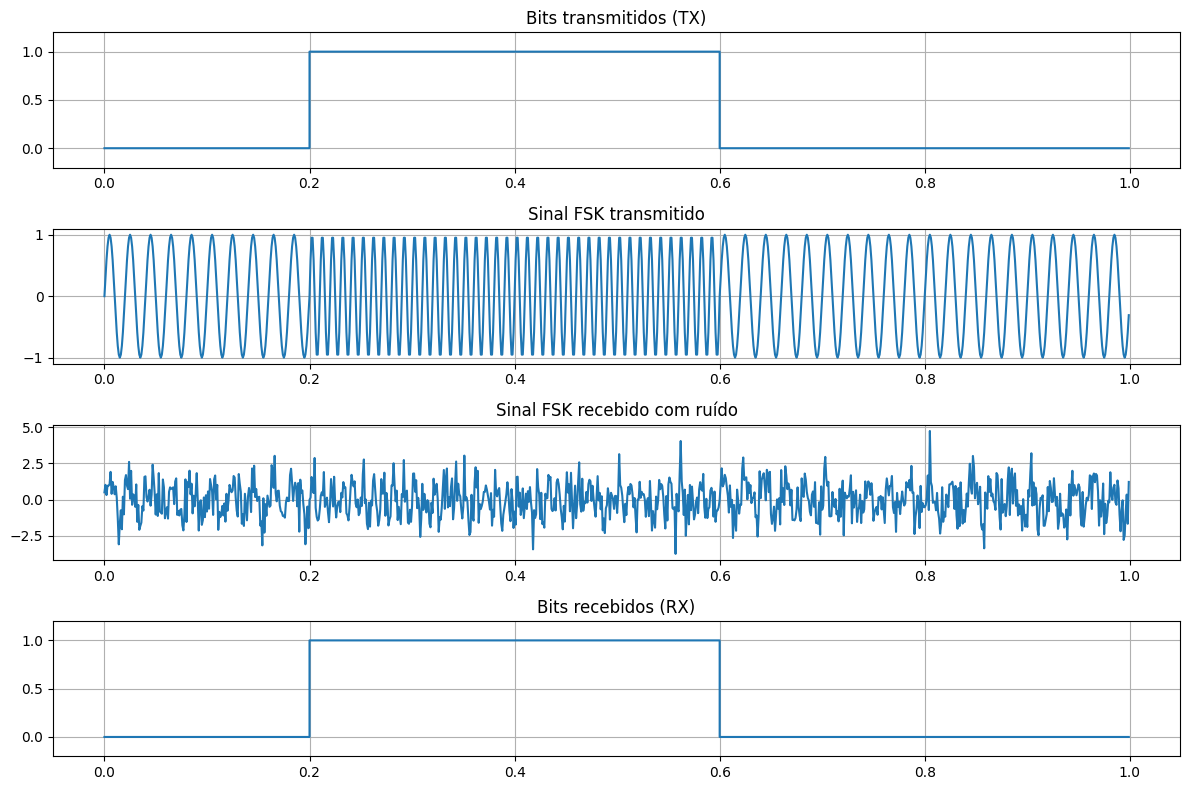

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# PARÂMETROS
# ==============================
num_bits = 10              # quantidade de bits gerados
amostras_por_bit = 100     # número de amostras para os bits
fs = 1000                  # frequência de amostragem
f0 = 50                    # frequência para bit 0
f1 = 100                   # frequência para bit 1
ruido = 1                  # intensidade do ruído

# ==============================
# GERAÇÃO DOS BITS ALEATÓRIOS
# ==============================
bits = np.random.randint(0, 2, num_bits)
print("Bits TX:", bits)

# Tempo de 1 bit
t_bit = np.arange(amostras_por_bit) / fs

# ==============================
# MODULAÇÃO FSK
# ==============================
sinal = []

for bit in bits:
    if bit == 0:
        modulado = np.sin(2 * np.pi * f0 * t_bit)
    else:
        modulado = np.sin(2 * np.pi * f1 * t_bit)

    sinal.extend(modulado)

sinal = np.array(sinal)

# ==============================
# ADIÇÃO DE RUÍDO
# ==============================
sinal_rx = sinal + ruido * np.random.randn(len(sinal))

# ==============================
# DEMODULAÇÃO FSK
# ==============================
bits_recebidos = []

ref0 = np.sin(2 * np.pi * f0 * t_bit) # Sinais de referência
ref1 = np.sin(2 * np.pi * f1 * t_bit)

for i in range(num_bits):
    inicio = i * amostras_por_bit
    fim = inicio + amostras_por_bit
    periodo = sinal_rx[inicio:fim]

    c0 = np.sum(periodo * ref0) # Cáluculo de correlação
    c1 = np.sum(periodo * ref1)

    if abs(c1) > abs(c0): # Maior similaridade com c1
        bits_recebidos.append(1)
    else:                 # Maior similaridade com c0
        bits_recebidos.append(0)

bits_recebidos = np.array(bits_recebidos)

print("Bits RX:", bits_recebidos)

# ==============================
# TAXA DE ERRO
# ==============================
erros = np.sum(bits != bits_recebidos)
print("Erros:", erros)
print("BER:", erros/num_bits)

# ==============================
# VISUALIZAÇÃO BITS TX E RX
# ==============================
# Repete cada bit pelo número de amostras do bit
bits_tx_plot = np.repeat(bits, amostras_por_bit)
bits_rx_plot = np.repeat(bits_recebidos, amostras_por_bit)

tempo_total = np.arange(len(sinal)) / fs

# ==============================
# GRÁFICOS
# ==============================
plt.figure(figsize=(12, 8))

# Bits transmitidos
plt.subplot(4, 1, 1)
plt.plot(tempo_total, bits_tx_plot, drawstyle='steps-post')
plt.title("Bits transmitidos (TX)")
plt.ylim(-0.2, 1.2)
plt.grid()

# Sinal FSK transmitido
plt.subplot(4, 1, 2)
plt.plot(tempo_total, sinal)
plt.title("Sinal FSK transmitido")
plt.grid()

# Sinal recebido com ruído
plt.subplot(4, 1, 3)
plt.plot(tempo_total, sinal_rx)
plt.title("Sinal FSK recebido com ruído")
plt.grid()

# Bits recebidos
plt.subplot(4, 1, 4)
plt.plot(tempo_total, bits_rx_plot, drawstyle='steps-post')
plt.title("Bits recebidos (RX)")
plt.ylim(-0.2, 1.2)
plt.grid()

plt.tight_layout()
plt.show()

Bits TX: [0 1 1 ... 1 1 1]
Bits RX: [0 1 1 ... 1 1 1]
Erros: 886
BER: 0.0886


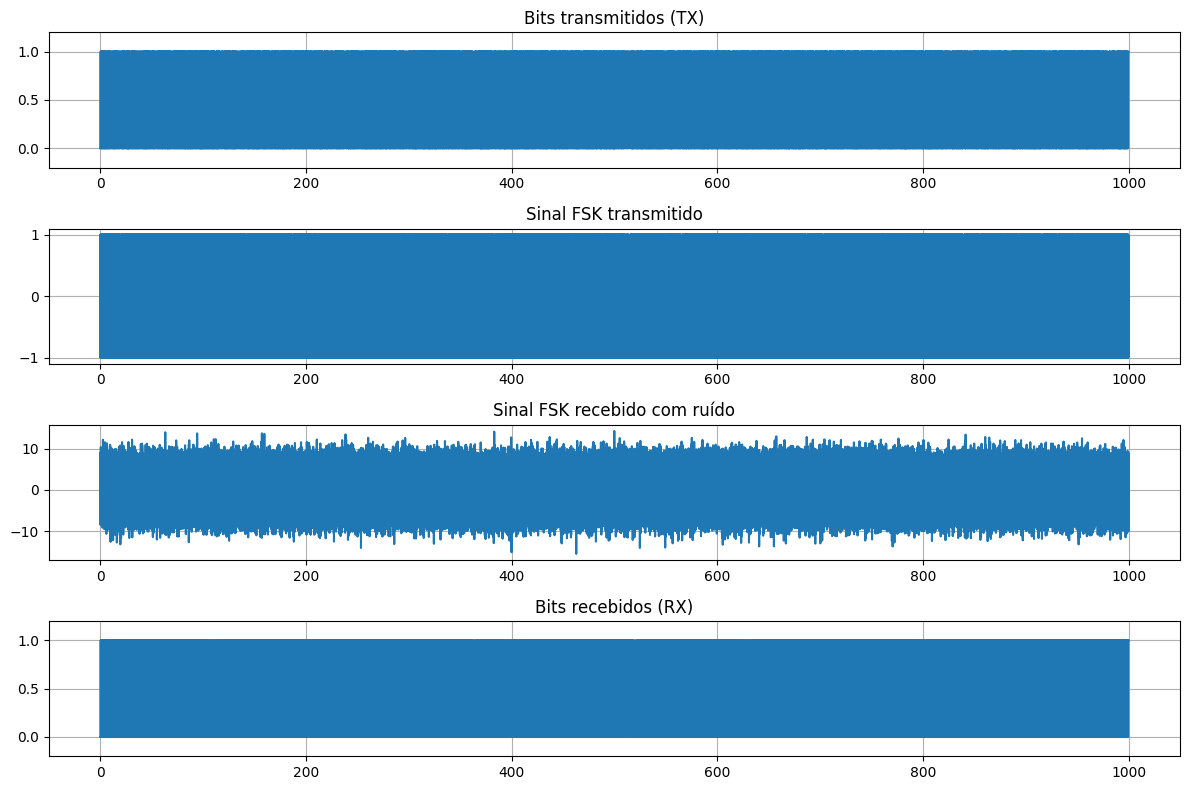

In [2]:
#_________________________________________________________________________________
#
# Teste com mais bits e aumentando a intensidade do ruído para visualizar a BER
#_________________________________________________________________________________

import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# PARÂMETROS
# ==============================
num_bits = 10000              # quantidade de bits gerados
amostras_por_bit = 100     # número de amostras para os bits
fs = 1000                  # frequência de amostragem
f0 = 50                    # frequência para bit 0
f1 = 100                   # frequência para bit 1
ruido = 3               # intensidade do ruído

# ==============================
# GERAÇÃO DOS BITS ALEATÓRIOS
# ==============================
bits = np.random.randint(0, 2, num_bits)
print("Bits TX:", bits)

# Tempo de 1 bit
t_bit = np.arange(amostras_por_bit) / fs

# ==============================
# MODULAÇÃO FSK
# ==============================
sinal = []

for bit in bits:
    if bit == 0:
        modulado = np.sin(2 * np.pi * f0 * t_bit)
    else:
        modulado = np.sin(2 * np.pi * f1 * t_bit)

    sinal.extend(modulado)

sinal = np.array(sinal)

# ==============================
# ADIÇÃO DE RUÍDO
# ==============================
sinal_rx = sinal + ruido * np.random.randn(len(sinal))

# ==============================
# DEMODULAÇÃO FSK
# ==============================
bits_recebidos = []

ref0 = np.sin(2 * np.pi * f0 * t_bit) # Sinais de referência
ref1 = np.sin(2 * np.pi * f1 * t_bit)

for i in range(num_bits):
    inicio = i * amostras_por_bit
    fim = inicio + amostras_por_bit
    periodo = sinal_rx[inicio:fim]

    c0 = np.sum(periodo * ref0) # Cáluculo de correlação
    c1 = np.sum(periodo * ref1)

    if abs(c1) > abs(c0): # Maior similaridade com c1
        bits_recebidos.append(1)
    else:                 # Maior similaridade com c0
        bits_recebidos.append(0)

bits_recebidos = np.array(bits_recebidos)

print("Bits RX:", bits_recebidos)

# ==============================
# TAXA DE ERRO
# ==============================
erros = np.sum(bits != bits_recebidos)
print("Erros:", erros)
print("BER:", erros/num_bits)

# ==============================
# VISUALIZAÇÃO BITS TX E RX
# ==============================
# Repete cada bit pelo número de amostras do bit
bits_tx_plot = np.repeat(bits, amostras_por_bit)
bits_rx_plot = np.repeat(bits_recebidos, amostras_por_bit)

tempo_total = np.arange(len(sinal)) / fs

# ==============================
# GRÁFICOS
# ==============================
plt.figure(figsize=(12, 8))

# Bits transmitidos
plt.subplot(4, 1, 1)
plt.plot(tempo_total, bits_tx_plot, drawstyle='steps-post')
plt.title("Bits transmitidos (TX)")
plt.ylim(-0.2, 1.2)
plt.grid()

# Sinal FSK transmitido
plt.subplot(4, 1, 2)
plt.plot(tempo_total, sinal)
plt.title("Sinal FSK transmitido")
plt.grid()

# Sinal recebido com ruído
plt.subplot(4, 1, 3)
plt.plot(tempo_total, sinal_rx)
plt.title("Sinal FSK recebido com ruído")
plt.grid()

# Bits recebidos
plt.subplot(4, 1, 4)
plt.plot(tempo_total, bits_rx_plot, drawstyle='steps-post')
plt.title("Bits recebidos (RX)")
plt.ylim(-0.2, 1.2)
plt.grid()

plt.tight_layout()
plt.show()

Bits TX: [0 1 0 1 0 1 0 1 0 1 1 1 1 1 1 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0]
Bits RX: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Erros: 16
BER: 0.5333333333333333


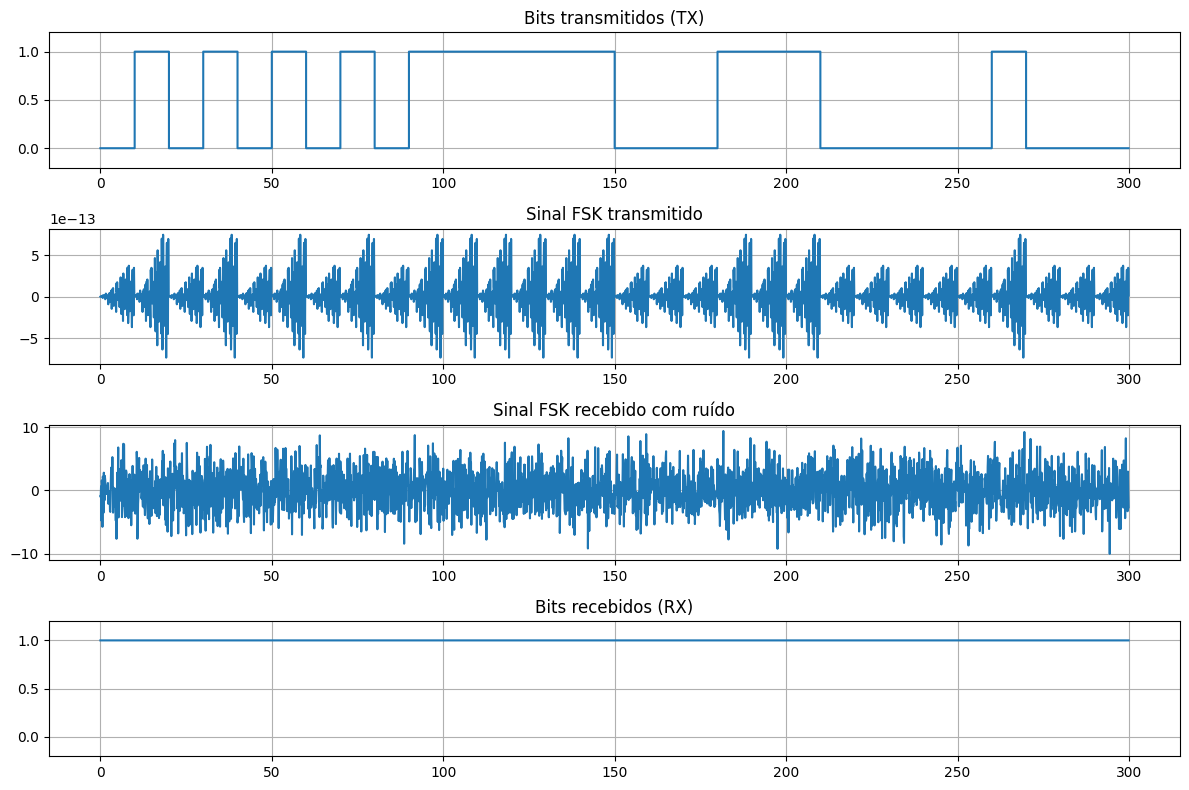

In [3]:
#____________________________________________________
#
# Teste com frequência de amostragem baixa
#____________________________________________________

import numpy as np
import matplotlib.pyplot as plt

# ==============================
# PARÂMETROS
# ==============================
num_bits = 30              # quantidade de bits gerados
amostras_por_bit = 100     # número de amostras para os bits
fs = 10                  # frequência de amostragem
f0 = 50                    # frequência para bit 0
f1 = 100                   # frequência para bit 1
ruido = 3               # intensidade do ruído

# ==============================
# GERAÇÃO DOS BITS ALEATÓRIOS
# ==============================
bits = np.random.randint(0, 2, num_bits)
print("Bits TX:", bits)

# Tempo de 1 bit
t_bit = np.arange(amostras_por_bit) / fs

# ==============================
# MODULAÇÃO FSK
# ==============================
sinal = []

for bit in bits:
    if bit == 0:
        modulado = np.sin(2 * np.pi * f0 * t_bit)
    else:
        modulado = np.sin(2 * np.pi * f1 * t_bit)

    sinal.extend(modulado)

sinal = np.array(sinal)

# ==============================
# ADIÇÃO DE RUÍDO
# ==============================
sinal_rx = sinal + ruido * np.random.randn(len(sinal))

# ==============================
# DEMODULAÇÃO FSK
# ==============================
bits_recebidos = []

ref0 = np.sin(2 * np.pi * f0 * t_bit) # Sinais de referência
ref1 = np.sin(2 * np.pi * f1 * t_bit)

for i in range(num_bits):
    inicio = i * amostras_por_bit
    fim = inicio + amostras_por_bit
    periodo = sinal_rx[inicio:fim]

    c0 = np.sum(periodo * ref0) # Cáluculo de correlação
    c1 = np.sum(periodo * ref1)

    if abs(c1) > abs(c0): # Maior similaridade com c1
        bits_recebidos.append(1)
    else:                 # Maior similaridade com c0
        bits_recebidos.append(0)

bits_recebidos = np.array(bits_recebidos)

print("Bits RX:", bits_recebidos)

# ==============================
# TAXA DE ERRO
# ==============================
erros = np.sum(bits != bits_recebidos)
print("Erros:", erros)
print("BER:", erros/num_bits)

# ==============================
# VISUALIZAÇÃO BITS TX E RX
# ==============================
# Repete cada bit pelo número de amostras do bit
bits_tx_plot = np.repeat(bits, amostras_por_bit)
bits_rx_plot = np.repeat(bits_recebidos, amostras_por_bit)

tempo_total = np.arange(len(sinal)) / fs

# ==============================
# GRÁFICOS
# ==============================
plt.figure(figsize=(12, 8))

# Bits transmitidos
plt.subplot(4, 1, 1)
plt.plot(tempo_total, bits_tx_plot, drawstyle='steps-post')
plt.title("Bits transmitidos (TX)")
plt.ylim(-0.2, 1.2)
plt.grid()

# Sinal FSK transmitido
plt.subplot(4, 1, 2)
plt.plot(tempo_total, sinal)
plt.title("Sinal FSK transmitido")
plt.grid()

# Sinal recebido com ruído
plt.subplot(4, 1, 3)
plt.plot(tempo_total, sinal_rx)
plt.title("Sinal FSK recebido com ruído")
plt.grid()

# Bits recebidos
plt.subplot(4, 1, 4)
plt.plot(tempo_total, bits_rx_plot, drawstyle='steps-post')
plt.title("Bits recebidos (RX)")
plt.ylim(-0.2, 1.2)
plt.grid()

plt.tight_layout()
plt.show()

Bits TX: [0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 1 0 1 0 0 1 1 0 1 1 0 0 1 0 0]
Bits RX: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
Erros: 13
BER: 0.43333333333333335


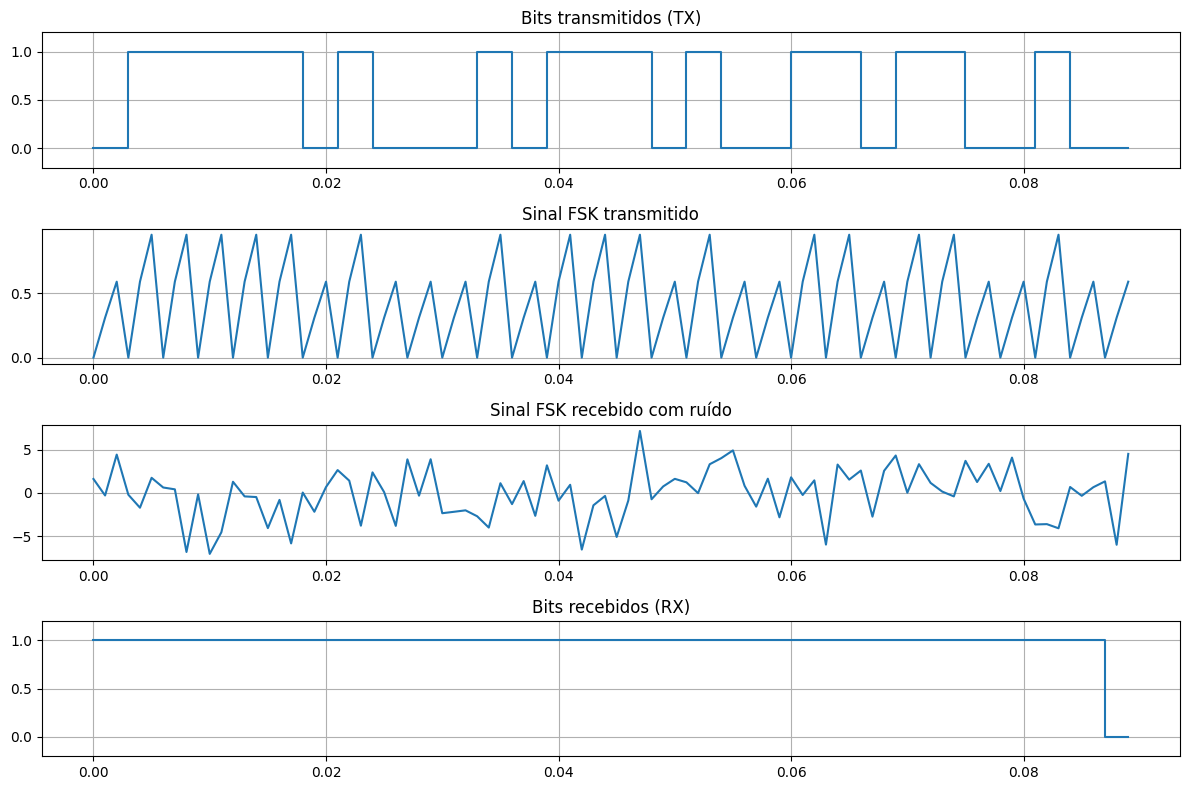

In [4]:

#____________________________________________________
#
# Teste com poucas amostras por bit
#____________________________________________________

import numpy as np
import matplotlib.pyplot as plt

# ==============================
# PARÂMETROS
# ==============================
num_bits = 30              # quantidade de bits gerados
amostras_por_bit = 3     # número de amostras para os bits
fs = 1000                  # frequência de amostragem
f0 = 50                    # frequência para bit 0
f1 = 100                   # frequência para bit 1
ruido = 3               # intensidade do ruído

# ==============================
# GERAÇÃO DOS BITS ALEATÓRIOS
# ==============================
bits = np.random.randint(0, 2, num_bits)
print("Bits TX:", bits)

# Tempo de 1 bit
t_bit = np.arange(amostras_por_bit) / fs

# ==============================
# MODULAÇÃO FSK
# ==============================
sinal = []

for bit in bits:
    if bit == 0:
        modulado = np.sin(2 * np.pi * f0 * t_bit)
    else:
        modulado = np.sin(2 * np.pi * f1 * t_bit)

    sinal.extend(modulado)

sinal = np.array(sinal)

# ==============================
# ADIÇÃO DE RUÍDO
# ==============================
sinal_rx = sinal + ruido * np.random.randn(len(sinal))

# ==============================
# DEMODULAÇÃO FSK
# ==============================
bits_recebidos = []

ref0 = np.sin(2 * np.pi * f0 * t_bit) # Sinais de referência
ref1 = np.sin(2 * np.pi * f1 * t_bit)

for i in range(num_bits):
    inicio = i * amostras_por_bit
    fim = inicio + amostras_por_bit
    periodo = sinal_rx[inicio:fim]

    c0 = np.sum(periodo * ref0) # Cáluculo de correlação
    c1 = np.sum(periodo * ref1)

    if abs(c1) > abs(c0): # Maior similaridade com c1
        bits_recebidos.append(1)
    else:                 # Maior similaridade com c0
        bits_recebidos.append(0)

bits_recebidos = np.array(bits_recebidos)

print("Bits RX:", bits_recebidos)

# ==============================
# TAXA DE ERRO
# ==============================
erros = np.sum(bits != bits_recebidos)
print("Erros:", erros)
print("BER:", erros/num_bits)

# ==============================
# VISUALIZAÇÃO BITS TX E RX
# ==============================
# Repete cada bit pelo número de amostras do bit
bits_tx_plot = np.repeat(bits, amostras_por_bit)
bits_rx_plot = np.repeat(bits_recebidos, amostras_por_bit)

tempo_total = np.arange(len(sinal)) / fs

# ==============================
# GRÁFICOS
# ==============================
plt.figure(figsize=(12, 8))

# Bits transmitidos
plt.subplot(4, 1, 1)
plt.plot(tempo_total, bits_tx_plot, drawstyle='steps-post')
plt.title("Bits transmitidos (TX)")
plt.ylim(-0.2, 1.2)
plt.grid()

# Sinal FSK transmitido
plt.subplot(4, 1, 2)
plt.plot(tempo_total, sinal)
plt.title("Sinal FSK transmitido")
plt.grid()

# Sinal recebido com ruído
plt.subplot(4, 1, 3)
plt.plot(tempo_total, sinal_rx)
plt.title("Sinal FSK recebido com ruído")
plt.grid()

# Bits recebidos
plt.subplot(4, 1, 4)
plt.plot(tempo_total, bits_rx_plot, drawstyle='steps-post')
plt.title("Bits recebidos (RX)")
plt.ylim(-0.2, 1.2)
plt.grid()

plt.tight_layout()
plt.show()